In [1]:
import json
import numpy as np
import pickle
from pyrocko import cake
import pandas as pd
from scipy.signal import detrend

import loader
import seaborn as sns
import matplotlib.pyplot as plt
import h5py
from loader import TrainDevTestSplitter

In [2]:
def plot_wave(x,ppk):
    plt.figure()
    
    fig, axes = plt.subplots(3, 1, figsize=(6, 8))

    # 在每个子图中绘制数据
    # 绘制竖线，表示p和s的值
    for i in range(3):
        axes[i].plot(x[:,i])
        axes[i].vlines(ppk,0,1,transform=axes[i].get_xaxis_transform(),colors='C1',label=f'{ppk/100.} sec')
        axes[i].set_title('channel {}'.format(i))
        axes[i].set_xlabel('Index')
        axes[i].set_ylabel('Value')
        axes[i].legend()
    # 调整子图之间的间距
    plt.tight_layout()
    plt.show()
    plt.close('all')

In [3]:
traveltime_model = cake.load_model('prem-no-ocean.m')

In [4]:
# Italy
conf_f = '/home/zhangb/git/pub/TEAM/mag_baseline_configs/italy.json'
res_f1 = '/home/zhangb/git/pub/TEAM/mag_baselines/italy/KuyukAllen/dev/predictions.pkl'
res_f2 = '/home/zhangb/git/pub/TEAM/mag_baselines/italy/KuyukAllen/test/predictions.pkl'
with open(conf_f, 'r') as f:
    config = json.load(f)
shuffle_train_dev = config.get('shuffle_train_dev', False)
custom_split = config.get('custom_split', None)
data_keys = config.get('data_keys', None)
times = config.get('times', (0.5, 1, 2, 4, 8, 16, 25))

In [5]:
# Chile
conf_f = '/home/zhangb/git/pub/TEAM/mag_baseline_configs/chile.json'
res_f1 = '/home/zhangb/git/pub/TEAM/mag_baselines/chile/KuyukAllen/dev/predictions.pkl'
res_f2 = '/home/zhangb/git/pub/TEAM/mag_baselines/chile/KuyukAllen/test/predictions.pkl'
with open(conf_f, 'r') as f:
    config = json.load(f)
shuffle_train_dev = config.get('shuffle_train_dev', False)
custom_split = config.get('custom_split', None)
data_keys = config.get('data_keys', None)
times = config.get('times', (0.5, 1, 2, 4, 8, 16, 25))

In [10]:
with open(res_f1,'rb') as f:
    res1 = pickle.load(f)

In [11]:
with open(res_f2,'rb') as f:
    res2 = pickle.load(f)

In [12]:
data_keys = ['coords','waveforms','p_picks']

### Load data use TEAM data loader

In [8]:
limit = None
act_set = 'dev'
event_metadata, data, metadata = loader.load_events(config['data_path'], limit=limit,
                                                    parts=(False, act_set == 'dev', act_set == 'test'),
                                                    shuffle_train_dev=shuffle_train_dev,
                                                    custom_split=custom_split, data_keys=data_keys)

KeyboardInterrupt: 

In [281]:
len(data['coords'])

705

### Load data manually

In [9]:
event_metadata = pd.read_hdf(config['data_path'], 'metadata/event_metadata')
meta_fname = 'TEAM_Italy_all_11s.csv'
# test dataset 
act_set = 'test'
parts=(False, act_set == 'dev', act_set == 'test')
if parts:
    mask = TrainDevTestSplitter.run_method(event_metadata, custom_split, shuffle_train_dev, parts=parts)
    event_metadata = event_metadata[mask]
meta_fname = 'TEAM_Italy_test_2016.csv'

In [10]:
meta_fname

'TEAM_Italy_test_2016.csv'

In [14]:
metadata = {}
data = {}
for event_key in ['KiK_File', '#EventID', 'EVENT']:
    if event_key in event_metadata.columns:
        break
wave_meta ={event_key:[],'waveform_id':[], 'p_target':[], 'STA_Lat':[],'STA_Lon':[],'STA_Alt':[]}
decimate = 1
with h5py.File(config['data_path'], 'r') as f:
    for key in f['metadata'].keys():
        if key == 'event_metadata':
            continue
        #metadata[key] = f['metadata'][key].value
        metadata[key] = f['metadata'][key][()]

    skipped = 0
    contained = []
    for _, event in event_metadata.iterrows():
        event_name = str(event[event_key])
        if event_name not in f['data']:
            skipped += 1
            contained += [False]
            continue
        contained += [True]
        g_event = f['data'][event_name]
        # for key in g_event:
        #     if data_keys is not None and key not in data_keys:
        #         continue
        #     if key not in data:
        #         data[key] = []
        #     if key == 'waveforms':
        #         # data[key] += [g_event[key][:, ::decimate, :]]
        #         pass
        #     else:
        #         #data[key] += [g_event[key].value]
        #         data[key] = np.array(g_event[key][()])
        #     if key == 'p_picks':
        #         data[key][-1] //= decimate
        p_picks = np.array(g_event['p_picks'][()]).astype(np.float32) 
        coords = np.array(g_event['coords'][()]).astype(np.float32) 
        wvfms = g_event['waveforms'][:, ::decimate, :]
        n_wave = coords.shape[0]
        mask = (p_picks < 3000 - 11*100) & (p_picks > 0)
        tmp_ind = np.arange(n_wave)
        tmp_ind = tmp_ind[mask]
        n_wave = len(tmp_ind)
        if n_wave > 0:
            wave_meta[event_key].extend([event_name]*n_wave)
            wave_meta['waveform_id'].append(tmp_ind)
            wave_meta['p_target'].append(p_picks[mask])
            coords = coords[mask]
            wave_meta['STA_Lat'].append(coords[:,0])
            wave_meta['STA_Lon'].append(coords[:,1])
            wave_meta['STA_Alt'].append(coords[:,2])
        # wave_meta[event_key].extend([event_name]*n_wave)
        # wave_meta['waveform_id'].append(np.arange(n_wave))

    if len(contained) < len(event_metadata):
        contained += [True for _ in range(len(event_metadata) - len(contained))]
    event_metadata = event_metadata[contained]
    wave_meta['waveform_id'] = np.hstack(wave_meta['waveform_id'])
    # wave_meta['p_target'] = np.hstack(data['p_picks'])
    wave_meta['p_target'] = np.hstack(wave_meta['p_target'])
    wave_meta['STA_Lat'] = np.hstack(wave_meta['STA_Lat'])
    wave_meta['STA_Lon'] = np.hstack(wave_meta['STA_Lon'])
    wave_meta['STA_Alt'] = np.hstack(wave_meta['STA_Alt'])
    wave_meta['s_target'] = np.nan
    wave_meta = pd.DataFrame(wave_meta)
    wave_meta[event_key] = wave_meta[event_key].astype(int)
    res_meta = event_metadata.merge(wave_meta,on=event_key)
    if skipped > 0:
        print(f'Skipped {skipped} events')

# res_meta['STA_Lat'] = np.vstack(data['coords'])[:,0]
# res_meta['STA_Lon'] = np.vstack(data['coords'])[:,1]
# res_meta['STA_Alt'] = np.vstack(data['coords'])[:,2]
R = 6371.
dLat = np.deg2rad(res_meta['Latitude'] - res_meta['STA_Lat'])
dLon = np.deg2rad(res_meta['Longitude'] - res_meta['STA_Lon'])
a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(np.deg2rad(res_meta['STA_Lat'])) * np.cos(np.deg2rad(res_meta['Latitude'])) * np.sin(dLon/2)*np.sin(dLon/2)
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
d = R * c 
res_meta['Dis'] = d

res_meta['From'] = 'Team_Italy'
res_meta.rename(columns={'Magnitude':'Mag_value',event_key:'Key'},inplace=True)

res_meta.to_csv(f'/run/media/zhangb/My Passport/TEAM_DATA/italy/{meta_fname}',index=False)

In [347]:
for key in wave_meta.keys():
    print(key,len(wave_meta[key]))

#EventID 255368
waveform_id 255368
p_target 255368
s_target 255368


In [540]:
len(res_meta)

177654

In [612]:
def get_team_italy_data(f,key,i_wav):
    dataset = f['data'][str(key)]['waveforms']
    ppk = f['data'][str(key)]['p_picks'][()]
    coords = f['data'][str(key)]['coords'][()]
    print(ppk)
    ppk = np.array(ppk).astype(int)[i_wav]
    data_t = np.array(dataset).astype(np.float64)[i_wav]
    data = data_t
    # data_t = data_t - np.mean(data_t,axis=0,keepdims=True)
    # data = np.zeros([3000,3])
    # l = min(len(data_t),len(data))
    # data[:l,0] = data_t[:l,2] #Z
    # data[:l,1] = data_t[:l,0] #N
    # data[:l,2] = data_t[:l,1] #E
    return data,ppk

def first_nonzero_index(array):
    """Return the index of the first non-zero element of array. If all elements are zero, return -1."""
    
    fnzi = 0 # first non-zero index
    indices = np.flatnonzero(array)
       
    if (len(indices) > 0):
        fnzi = indices[0]
        
    return fnzi

163004 41
[4620 7127 6887 7152 6698 6605 4728 5532 7462 2076  604 1174 3211  664
 2221 1156 1577 3359 1298  607 3456 1423 2797  945 3049 3027 3749 1151
 1223 1211 2643 3295 1314 1141  672 1068  655 1911 2216 2063  921  954
 3550 2778 2986 2611  794 2588 3402 1923 1927 1926 1922 3742 1432 1074
  839 1085 2952 5733 2358 5219 1502 1883 1920 2130 1873 2087 5806 4808
 4338 5403 6607 5574 3322 4679 2244 5903 6375 2351 6383 2736 1812 5673
 2829 3784 5239 6019 3943  899 5195 1038 1592 5404 3695 1142 6969 2328
 5600 5449 4940 1390 6112 3719 6287 6345 1824 4994 6202  851 1390 4878
 4143 5206 1159 4284 1473 4616  723 4325 1803 5636 5740  624 5664 4074
 2263 2243 3512 1332 6508 7437 1893 3990  605 2667 5305 3640 2113 5544
 5102 5911 5874 1264 5534 6900 4666 5133 4760 4797 1432 1827 1439 5692
  500  849  517  957 4907 3196 5744 3887 5587 5167 4781 5461 5928 4907
 5309 7125 5153 6065 5752 5640 5456 5757 5332 5789 5948 5579 5887 5648
 5413 6068 6835 6901 6801 6839 6762 6799 6775 6779 6852 6400 5540 5

<Figure size 640x480 with 0 Axes>

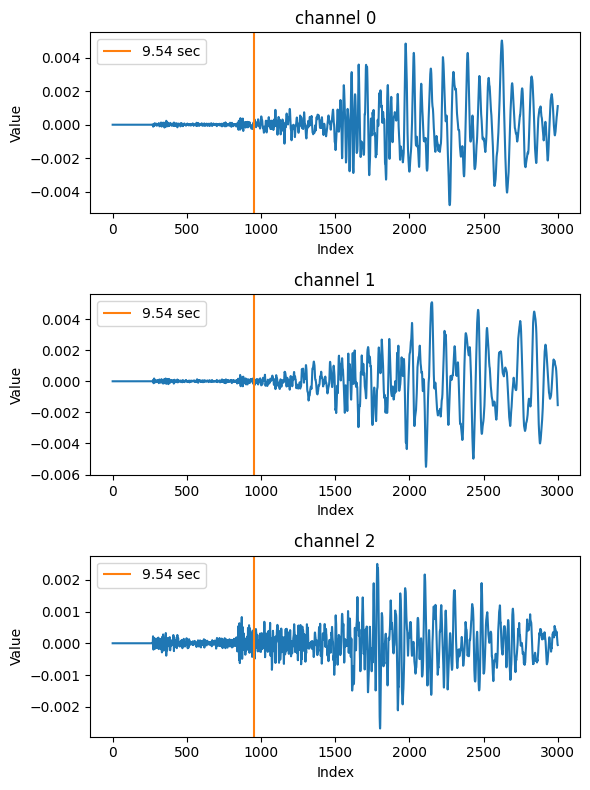

<Figure size 640x480 with 0 Axes>

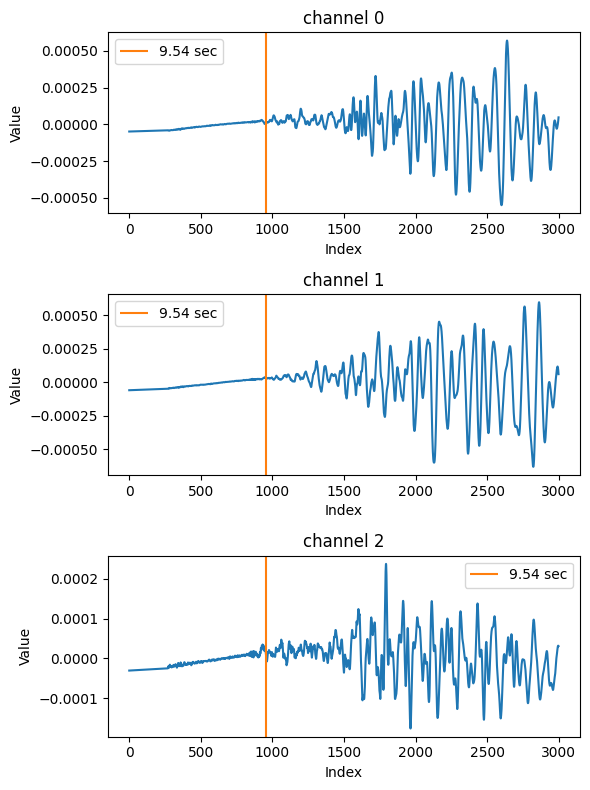

In [632]:
sampling_rate = 100
snr_threshold = 3
ind = np.random.randint(len(res_meta))
key = res_meta.iloc[ind]['Key']
i_wav = res_meta.iloc[ind]['waveform_id']
print(ind,i_wav)
with h5py.File(config['data_path'], 'r') as f:
    wv,ppk = get_team_italy_data(f,key,i_wav)
if ppk > 3000 or ppk == 0:
    print('bad p pick!', ppk)
else:
    print('good p pick!', ppk)
# ind = np.random.randint(len(data['coords']))
# i_wav = np.random.randint(data['p_picks'][ind].shape[0])
# wv = data['waveforms'][ind][i_wav]
# ppk = data['p_picks'][ind][i_wav] 

val = np.max(np.abs(wv[ppk:ppk + 4 * sampling_rate,2]))
noise = np.max(np.abs(wv[ppk - 2 * sampling_rate:ppk - sampling_rate,2]))
print('val:', val, 'noise:', noise)
if noise * snr_threshold > val:
    print('noise too big!')
fnzi = np.min(np.apply_along_axis(first_nonzero_index,axis=0,arr=wv))
wv[fnzi:] = detrend(wv[fnzi:],axis=0,type='linear')
wv[fnzi:] = detrend(wv[fnzi:],axis=0,type='constant')
plot_wave(wv,ppk)
wv_v = np.cumsum(wv,axis=0)/100.
wv_v = detrend(wv_v,axis=0,type='linear')
wv_v = detrend(wv_v,axis=0,type='constant')
plot_wave(wv_v,ppk)

In [654]:
pd.concat([res_meta.iloc[0:1],res_meta.iloc[1:2]])
# pd.concat([tmp,res_meta.iloc[1:2]])

,Key,Time,Latitude,Longitude,Depth/Km,Author,Catalog,Contributor,ContributorID,MagType,...,Depth_RAN,Nrecs_RAN,waveform_id,p_target,STA_Lat,STA_Lon,STA_Alt,s_target,Dis,From
0,1793039,2008-01-21T11:02:49.640000,43.930,10.174,3.1,BULLETIN-SISPICK,NaN,NaN,NaN,ML,...,NaN,NaN,0,500.0,43.986,7.55317,-0.595,NaN,209.864045,Team_Italy
1,1793119,2008-01-21T16:40:36.090000,46.696,9.532,2.0,BULLETIN-SISPICK,NaN,NaN,NaN,ML,...,NaN,NaN,0,1262.0,43.986,7.55317,-0.595,NaN,338.681435,Team_Italy


<Axes: >

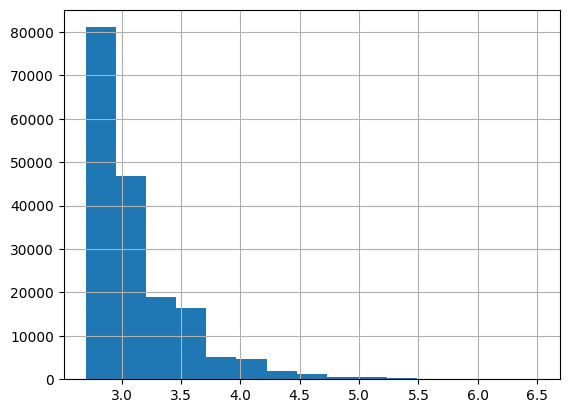

In [641]:
res_meta['Mag_value'].hist(bins=15)

<Figure size 640x480 with 0 Axes>

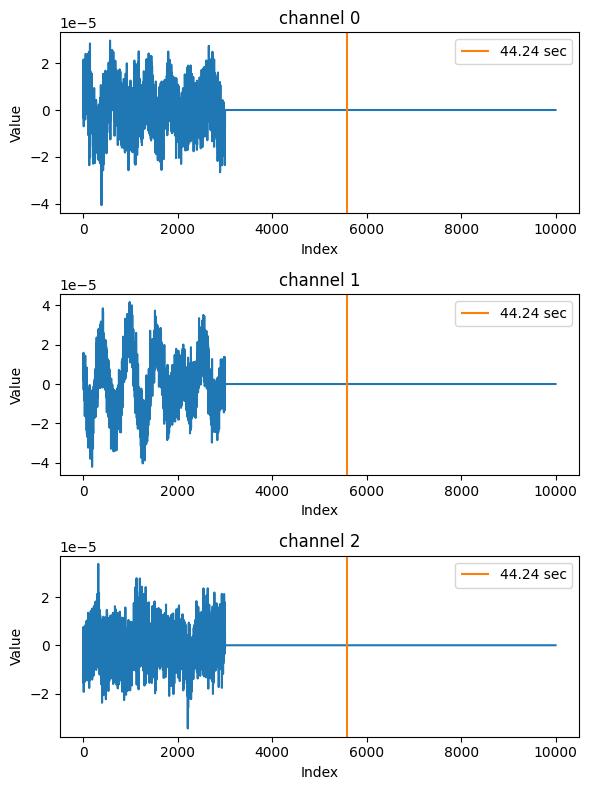

In [9]:
event_metadata

,#EventID,Time,Latitude,Longitude,Depth/Km,Author,Catalog,Contributor,ContributorID,MagType,...,MagAuthor,EventLocationName,Timestamp,id_RAN,title_RAN,Origin_Time(str)_RAN,Origin_Time_RAN,Ml_RAN,Depth_RAN,Nrecs_RAN
52535,1797709,2008-02-16T22:12:16.820000,43.1120,10.7700,16.2,BULLETIN-SISPICK,NaN,NaN,NaN,ML,...,--,8 km W Monterotondo Marittimo (GR),1.203200e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52822,1808419,2008-03-31T00:14:35.650000,42.6190,18.0010,10.0,BULLETIN-SISPICK,NaN,NaN,NaN,ML,...,--,Costa Croata meridionale (CROAZIA),1.206922e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53097,1823409,2008-06-07T04:25:10.240000,44.8900,11.2710,1.3,BULLETIN-SISPICK,NaN,NaN,NaN,ML,...,--,7 km NW Finale Emilia (MO),1.212813e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53439,1843669,2008-08-19T16:55:24.860000,44.8730,11.1860,1.0,BULLETIN-SISPICK,NaN,NaN,NaN,ML,...,--,5 km NE San Felice sul Panaro (MO),1.219165e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53692,1859999,2008-10-24T03:06:39.160000,44.3610,7.2750,15.2,BULLETIN-SISPICK,NaN,NaN,NaN,ML,...,--,5 km NW Demonte (CN),1.224818e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95635,23560331,2019-12-09T04:29:23.390000,44.0088,11.2950,9.2,SURVEY-INGV,NaN,NaN,NaN,ML,...,--,5 km E Barberino di Mugello (FI),1.575866e+09,431262.0,"Barberino di Mugello, Firenze",2019-12-09 04:29:23,1.575866e+09,3.2,9.2,27.0
95647,23562721,2019-12-09T07:07:35.730000,44.0077,11.3008,7.5,SURVEY-INGV,NaN,NaN,NaN,ML,...,--,5 km E Barberino di Mugello (FI),1.575875e+09,431342.0,"Barberino di Mugello, Firenze",2019-12-09 07:07:35,1.575875e+09,2.8,7.5,12.0
95650,23563681,2019-12-09T09:17:17.930000,44.0112,11.3088,7.4,SURVEY-INGV,NaN,NaN,NaN,ML,...,--,5 km N Scarperia e San Piero (FI),1.575883e+09,431360.0,"Scarperia, Firenze",2019-12-09 09:17:17,1.575883e+09,3.3,7.4,22.0
95672,23583211,2019-12-12T10:33:31.520000,44.6317,9.9727,24.7,SURVEY-INGV,NaN,NaN,NaN,ML,...,--,2 km NW Solignano (PR),1.576147e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1]:
event_metadata.columns

NameError: name 'event_metadata' is not defined

In [29]:
res2[2][10,6].shape

(100,)

In [31]:
col = 3
pred = pd.Series(res2[1][:,col])
tgt = event_metadata['Magnitude'][pred.notna().values]
pred.dropna(inplace=True)
cmp = pd.DataFrame({'tgt':tgt.values,'pred':pred.values})

In [32]:
rmse = (cmp['pred'] - cmp['tgt'])**2
rmse = np.sqrt(rmse.mean())
print(rmse)

0.8454018062516335


In [33]:
mean = cmp['tgt'].mean()
ssr = ((cmp['pred'] - cmp['tgt'])**2).sum()
sst = ((cmp['tgt'] - mean)**2).sum()
r2 = 1 - ssr/sst
print(r2)

-3.5078803449753693


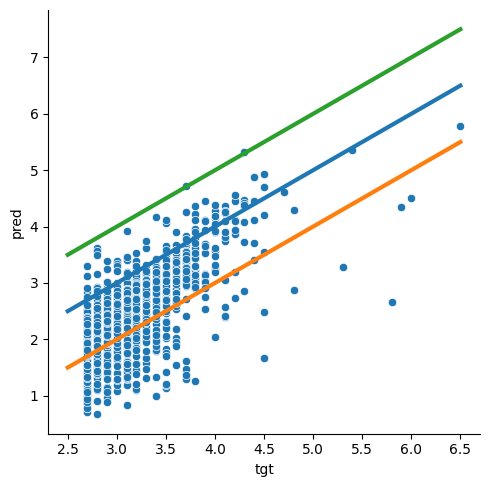

In [34]:
sns.relplot(data=cmp,x='tgt',y='pred')
plt.plot([2.5,6.5],[2.5,6.5],lw=3)
plt.plot([2.5,6.5],[1.5,5.5],lw=3)
plt.plot([2.5,6.5],[3.5,7.5],lw=3)
plt.show()
plt.close('all')